In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd

In [2]:
data = fits.open("/user/p5_lecturer/KiDS1000/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits")

In [3]:
data.info

<bound method HDUList.info of [<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7ca8b73e8ec0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ca8b73ea660>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ca8b739fc50>]>

In [4]:
table1 = Table.read(data[1])

In [5]:
tab_pan = table1.to_pandas()

In [6]:
read1 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO1_Nz.asc")
read2 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO2_Nz.asc")
read3 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO3_Nz.asc")
read4 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO4_Nz.asc")
read5 = np.loadtxt("/user/p5_lecturer/KiDS1000/SOM_N_of_Z/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO5_Nz.asc")

In [7]:
area1 = np.trapezoid(read1[:,1], read1[:,0])
area2 = np.trapezoid(read2[:,1], read2[:,0])
area3 = np.trapezoid(read3[:,1], read3[:,0])
area4 = np.trapezoid(read4[:,1], read4[:,0])
area5 = np.trapezoid(read5[:,1], read5[:,0])

In [8]:
print(area1, area2, area3, area4, area5)

0.049829818840774406 0.04996697254378173 0.04997802958921659 0.04998783562045754 0.05


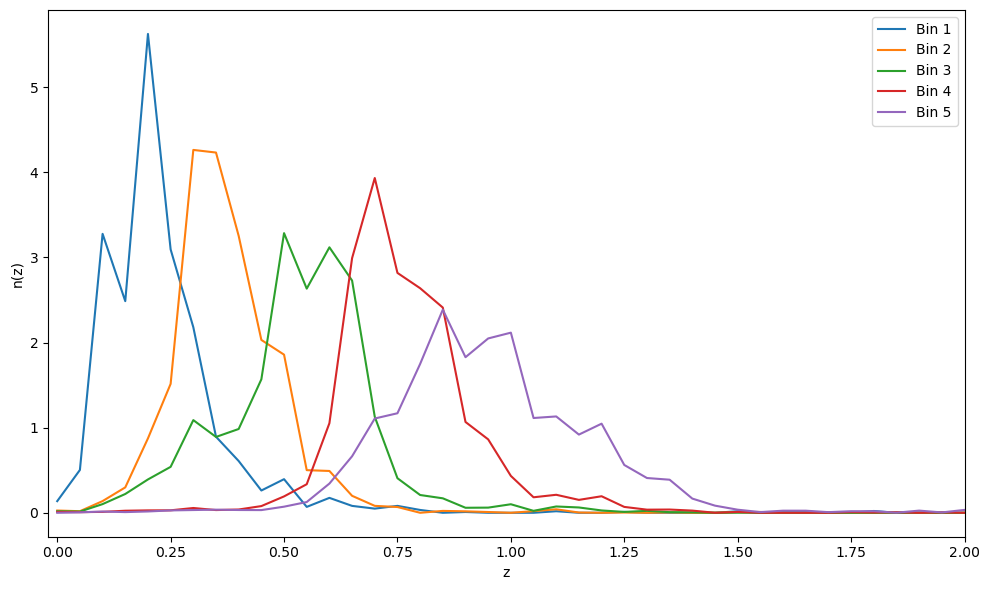

In [9]:
plt.figure(figsize=(10,6))
plt.plot(read1[:,0], read1[:,1]/area1, label=r'Bin 1')
plt.plot(read2[:,0], read2[:,1]/area2, label=r'Bin 2')
plt.plot(read3[:,0], read3[:,1]/area3, label=r'Bin 3')
plt.plot(read4[:,0], read4[:,1]/area4, label=r'Bin 4')
plt.plot(read5[:,0], read5[:,1]/area5, label=r'Bin 5')
plt.xlim(-0.02,2)
plt.xlabel(r"z")
plt.ylabel(r"n(z)")
plt.legend()
plt.tight_layout()
plt.savefig("bins.png")
plt.show()

In [10]:
print("diff1: ", read1[:,0].max() - read1[:,0].min())
print("diff2: ", read2[:,0].max() - read2[:,0].min())
print("diff3: ", read3[:,0].max() - read3[:,0].min())
print("diff4: ", read4[:,0].max() - read4[:,0].min())
print("diff5: ", read5[:,0].max() - read5[:,0].min())

diff1:  5.95
diff2:  5.95
diff3:  5.95
diff4:  5.95
diff5:  5.95


## Area with limits

In [11]:
mask1 = (read1[:,0] > 0.1) & (read1[:,0] <= 0.3)
mask2 = (read2[:,0] > 0.3) & (read2[:,0] <= 0.5)
mask3 = (read3[:,0] > 0.5) & (read3[:,0] <= 0.7)
mask4 = (read4[:,0] > 0.7) & (read4[:,0] <= 0.9)
mask5 = (read5[:,0] > 0.9) & (read5[:,0] <= 1.2)
ar1 = np.trapezoid(read1[:,1][mask1]/area1, read1[:,0][mask1])
ar2 = np.trapezoid(read2[:,1][mask2]/area2, read2[:,0][mask2])
ar3 = np.trapezoid(read3[:,1][mask3]/area3, read3[:,0][mask3])
ar4 = np.trapezoid(read4[:,1][mask4]/area4, read4[:,0][mask4])
ar5 = np.trapezoid(read5[:,1][mask5]/area5, read5[:,0][mask5])


In [12]:
print(ar1, ar2, ar3, ar4, ar5)

0.4207831325701369 0.6287929953531888 0.28997051930231765 0.5183503093204749 0.2922356954685884


In [13]:
print("Bin1 :", round(ar1,3))
print("Bin2 :", round(ar2,3))
print("Bin3 :", round(ar3,3))
print("Bin4 :", round(ar4,3))
print("Bin5 :", round(ar5,3))

Bin1 : 0.421
Bin2 : 0.629
Bin3 : 0.29
Bin4 : 0.518
Bin5 : 0.292


In [14]:
len(tab_pan)

21262011

In [15]:
table2 = Table.read(data[2])

In [16]:
tab_pan1 = table2.to_pandas()

In [17]:
len(tab_pan1)

32456

In [18]:
tab_pan1.columns

Index(['OBJECT_POS', 'OBJECT_COUNT', 'CHANNEL_NR', 'CHANNEL_NAME', 'SubNr'], dtype='object')

In [19]:
tab_pan.columns

Index(['SeqNr', 'SLID', 'SID', 'ID', 'FLUX_AUTO', 'FLUXERR_AUTO', 'MAG_AUTO',
       'MAGERR_AUTO', 'KRON_RADIUS', 'BackGr',
       ...
       'PSF_e2_exp3', 'PSF_e1_exp4', 'PSF_e2_exp4', 'PSF_e1_exp5',
       'PSF_e2_exp5', 'SeqNr_field', 'THELI_INT', 'e1', 'e2', 'weight'],
      dtype='object', length=193)

In [124]:
redshift = tab_pan['Z_B']
b1 = tab_pan[(tab_pan['Z_B'] > 0.1) & (tab_pan['Z_B'] <= 0.3)].copy()
b2 = tab_pan[(tab_pan['Z_B'] > 0.3) & (tab_pan['Z_B'] <= 0.5)].copy()
b3 = tab_pan[(tab_pan['Z_B'] > 0.5) & (tab_pan['Z_B'] <= 0.7)].copy()
b4 = tab_pan[(tab_pan['Z_B'] > 0.7) & (tab_pan['Z_B'] <= 0.9)].copy()
b5 = tab_pan[(tab_pan['Z_B'] > 0.9) & (tab_pan['Z_B'] <= 1.2)].copy()

In [203]:
c1bin1 = np.average(b1['e1'], weights=b1['weight'])
c2bin1 = np.average(b1['e2'], weights=b1['weight'])
corr_e1bin1 = b1['e1']-c1bin1
corr_e2bin1 = b1['e2']-c2bin1
b1['corr_e1'] = corr_e1bin1
b1['corr_e2'] = corr_e2bin1

c1bin2 = np.average(b2['e1'], weights=b2['weight'])
c2bin2 = np.average(b2['e2'], weights=b2['weight'])
corr_e1bin2 = b2['e1']-c1bin2
corr_e2bin2 = b2['e2']-c2bin2
b2['corr_e1'] = corr_e1bin2
b2['corr_e2'] = corr_e2bin2

c1bin3 = np.average(b3['e1'], weights=b3['weight'])
c2bin3 = np.average(b3['e2'], weights=b3['weight'])
corr_e1bin3 = b3['e1']-c1bin3
corr_e2bin3 = b3['e2']-c2bin3
b3['corr_e1'] = corr_e1bin3
b3['corr_e2'] = corr_e2bin3

c1bin4 = np.average(b4['e1'], weights=b4['weight'])
c2bin4 = np.average(b4['e2'], weights=b4['weight'])
corr_e1bin4 = b4['e1']-c1bin4
corr_e2bin4 = b4['e2']-c2bin4
b4['corr_e1'] = corr_e1bin4
b4['corr_e2'] = corr_e2bin4

c1bin5 = np.average(b5['e1'], weights=b5['weight'])
c2bin5 = np.average(b5['e2'], weights=b5['weight'])
corr_e1bin5 = b5['e1']-c1bin5
corr_e2bin5 = b5['e2']-c2bin5
b5['corr_e1'] = corr_e1bin5
b5['corr_e2'] = corr_e2bin5

In [205]:
b4['corr_e1'].hasnans

False

In [206]:
len(b1), len(b2), len(b3), len(b4), len(b5)

(1792136, 3681319, 6148102, 4544395, 5096059)

In [207]:
len(b1)+ len(b2)+ len(b3)+ len(b4)+ len(b5)

21262011

In [208]:
tab_pan['weight']

0            0.7116
1           15.5395
2           14.4574
3            6.7614
4            9.4653
             ...   
21262006     7.4016
21262007    12.6046
21262008    15.4484
21262009    15.0339
21262010     7.0869
Name: weight, Length: 21262011, dtype: float32

In [209]:
def n_eff(df):
    value = (1/2798640)*((np.sum(df['weight']))**2)/(np.sum((df['weight']**2)))
    return value

In [210]:
neff1 = n_eff(b1)
neff2 = n_eff(b2)
neff3 = n_eff(b3)
neff4 = n_eff(b4)
neff5 = n_eff(b5)

print(neff1, neff2, neff3, neff4, neff5)

0.6163804 1.1821303 1.8541169 1.2592063 1.3108858


In [211]:
import treecorr


In [212]:
b1_tab = Table.from_pandas(b1)
b2_tab = Table.from_pandas(b2)
b3_tab = Table.from_pandas(b3)
b4_tab = Table.from_pandas(b4)
b5_tab = Table.from_pandas(b5)
b1_tab.write("b1.fits", format="fits", overwrite=True)
b2_tab.write("b2.fits", format="fits", overwrite=True)
b3_tab.write("b3.fits", format="fits", overwrite=True)
b4_tab.write("b4.fits", format="fits", overwrite=True)
b5_tab.write("b5.fits", format="fits", overwrite=True)

In [213]:
cat11 = treecorr.Catalog("b1.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat22 = treecorr.Catalog("b2.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat33 = treecorr.Catalog("b3.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat44 = treecorr.Catalog("b4.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')
cat55 = treecorr.Catalog("b5.fits", ra_col='RAJ2000', dec_col='DECJ2000',
                       ra_units='degrees', dec_units='degrees', w_col ='weight',
                       g1_col='corr_e1', g2_col='corr_e2')

In [214]:
gg11 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9, 
                            sep_units='arcmin')
gg22 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg33 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg44 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg55 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg12 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg13 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg14 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg15 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg23 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg24 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg25 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg34 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg35 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')
gg45 = treecorr.GGCorrelation(min_sep=0.5, max_sep=300., nbins=9,
                            sep_units='arcmin')

In [215]:
gg11.process(cat11)
gg22.process(cat22)
gg33.process(cat33)
gg44.process(cat44)
gg55.process(cat55)

gg12.process(cat11, cat22)
gg13.process(cat11, cat33)
gg14.process(cat11, cat44)
gg15.process(cat11, cat55)

gg23.process(cat22, cat33)
gg24.process(cat22, cat44)
gg25.process(cat22, cat55)

gg34.process(cat33, cat44)
gg35.process(cat33, cat55)

gg45.process(cat44, cat55)


In [216]:
m1=-0.009
m2=-0.011
m3=-0.015
m4=0.002
m5=0.007

In [217]:
xip11 = gg11.xip/((1+m1)*(1+m1))
xim11 = gg11.xim  
# gg11.write('gg11.out') 

xip22 = gg22.xip/((1+m2)*(1+m2)) 
xim22 = gg22.xim  
# gg22.write('gg22.out')

xip33 = gg33.xip/((1+m3)*(1+m3))
xim33 = gg33.xim 
# gg33.write('gg33.out') 

xip44 = gg44.xip/((1+m4)*(1+m4))
xim44 = gg44.xim 
# gg44.write('gg44.out') 

xip55 = gg55.xip/((1+m5)*(1+m5)) 
xim55 = gg55.xim 

xim12 = gg12.xim 
xim13 = gg13.xim
xim14 = gg14.xim 
xim15 = gg15.xim 

xim23 = gg23.xim 
xim24 = gg24.xim 
xim25 = gg25.xim 

xim34 = gg34.xim 
xim35 = gg35.xim 

xim45 = gg45.xim 

xip12 = gg12.xip/((1+m1)*(1+m2)) 
xip13 = gg13.xip/((1+m1)*(1+m3))
xip14 = gg14.xip/((1+m1)*(1+m4))
xip15 = gg15.xip/((1+m1)*(1+m5))

xip23 = gg23.xip/((1+m2)*(1+m3)) 
xip24 = gg24.xip/((1+m2)*(1+m4))
xip25 = gg25.xip/((1+m2)*(1+m5))

xip34 = gg34.xip/((1+m3)*(1+m4)) 
xip35 = gg35.xip/((1+m3)*(1+m5)) 

xip45 = gg45.xip/((1+m4)*(1+m5)) 

In [218]:
r11 = gg11.meanr
sig11_xip = np.sqrt(gg11.varxip)
sig11_xim = np.sqrt(gg11.varxim)
r22 = gg22.meanr
sig22_xip = np.sqrt(gg22.varxip)
sig22_xim = np.sqrt(gg22.varxim)
r33 = gg33.meanr
sig33_xip = np.sqrt(gg33.varxip)
sig33_xim = np.sqrt(gg33.varxim)
r44 = gg44.meanr
sig44_xip = np.sqrt(gg44.varxip)
sig44_xim = np.sqrt(gg44.varxim)
r55 = gg55.meanr
sig55_xip = np.sqrt(gg55.varxip)
sig55_xim = np.sqrt(gg55.varxim)

r12 = gg12.meanr
sig12_xip = np.sqrt(gg12.varxip)
sig12_xim = np.sqrt(gg12.varxim)
r13 = gg13.meanr
sig13_xip = np.sqrt(gg13.varxip)
sig13_xim = np.sqrt(gg13.varxim)
r14 = gg14.meanr
sig14_xip = np.sqrt(gg14.varxip)
sig14_xim = np.sqrt(gg14.varxim)
r15 = gg15.meanr
sig15_xip = np.sqrt(gg15.varxip)
sig15_xim = np.sqrt(gg15.varxim)

r23 = gg23.meanr
sig23_xip = np.sqrt(gg23.varxip)
sig23_xim = np.sqrt(gg23.varxim)
r24 = gg24.meanr
sig24_xip = np.sqrt(gg24.varxip)
sig24_xim = np.sqrt(gg24.varxim)
r25 = gg25.meanr
sig25_xip = np.sqrt(gg25.varxip)
sig25_xim = np.sqrt(gg25.varxim)

r34 = gg34.meanr
sig34_xip = np.sqrt(gg34.varxip)
sig34_xim = np.sqrt(gg34.varxim)
r35 = gg35.meanr
sig35_xip = np.sqrt(gg35.varxip)
sig35_xim = np.sqrt(gg35.varxim)

r45 = gg45.meanr
sig45_xip = np.sqrt(gg45.varxip)
sig45_xim = np.sqrt(gg45.varxim)

In [219]:
all_r = [r11, r12, r13, r14, r15, r22, r23, r24, r25, r33, r34, r35, r44, r45, r55]
all_xip = [xip11, xip12, xip13, xip14, xip15, xip22, xip23, xip24, xip25, xip33, xip34, xip35, xip44, xip45, xip55]
all_xim = [xim11, xim12, xim13, xim14, xim15, xim22, xim23, xim24, xim25, xim33, xim34, xim35, xim44, xim45, xim55]
all_sig_xip = [sig11_xip, sig12_xip, sig13_xip, sig14_xip, sig15_xip, sig22_xip, sig23_xip, sig24_xip, sig25_xip, sig33_xip, sig34_xip, sig35_xip, sig44_xip, sig45_xip, sig55_xip]
all_sig_xim = [sig11_xim, sig12_xim, sig13_xim, sig14_xim, sig15_xim, sig22_xim, sig23_xim, sig24_xim, sig25_xim, sig33_xim, sig34_xim, sig35_xim, sig44_xim, sig45_xim, sig55_xim]
labels = ['11', '12', '13', '14', '15', '22', '23', '24', '25', '33', '34', '35', '44', '45', '55']

In [220]:
pub = fits.open("/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits")[2]

In [221]:
pub.data

FITS_rec([(1, 1, 1,  1.25115625e-04,   0.71336491),
          (1, 1, 2,  6.00683567e-06,   1.45209561),
          (1, 1, 3,  6.19317502e-05,   2.95582478),
          (1, 1, 4,  2.11742421e-06,   6.01675264),
          (1, 1, 5, -2.92882256e-06,  12.24744871),
          (1, 1, 6, -2.38991012e-06,  24.93039168),
          (1, 1, 7, -1.56889835e-06,  50.74725716),
          (1, 1, 8,  1.61541556e-07, 103.29898312),
          (1, 1, 9, -3.29682598e-09, 210.27106705),
          (1, 2, 1,  5.11868980e-05,   0.71336491),
          (1, 2, 2,  2.82597971e-05,   1.45209561),
          (1, 2, 3,  4.33571094e-06,   2.95582478),
          (1, 2, 4,  9.95191063e-06,   6.01675264),
          (1, 2, 5,  2.48591965e-06,  12.24744871),
          (1, 2, 6,  8.84065085e-07,  24.93039168),
          (1, 2, 7,  1.98120807e-06,  50.74725716),
          (1, 2, 8,  3.05569286e-07, 103.29898312),
          (1, 2, 9,  1.07653468e-07, 210.27106705),
          (1, 3, 1, -3.04513359e-05,   0.71336491),
          (1

In [222]:
pub1 = fits.open("/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits")[3]

In [223]:
pub1.data

FITS_rec([(1, 1, 1, -3.34523170e-05,   0.71336491),
          (1, 1, 2,  6.09317629e-05,   1.45209561),
          (1, 1, 3,  1.95391539e-05,   2.95582478),
          (1, 1, 4,  4.69729904e-06,   6.01675264),
          (1, 1, 5,  4.95813479e-06,  12.24744871),
          (1, 1, 6, -4.31260254e-06,  24.93039168),
          (1, 1, 7, -7.94992706e-07,  50.74725716),
          (1, 1, 8,  9.17260675e-08, 103.29898312),
          (1, 1, 9, -5.67160634e-07, 210.27106705),
          (1, 2, 1, -7.65705528e-05,   0.71336491),
          (1, 2, 2, -3.66969922e-05,   1.45209561),
          (1, 2, 3,  1.36146968e-05,   2.95582478),
          (1, 2, 4,  2.70414343e-06,   6.01675264),
          (1, 2, 5,  2.99412254e-06,  12.24744871),
          (1, 2, 6, -1.85781321e-07,  24.93039168),
          (1, 2, 7,  8.16703746e-07,  50.74725716),
          (1, 2, 8, -1.26269939e-07, 103.29898312),
          (1, 2, 9,  2.59555493e-07, 210.27106705),
          (1, 3, 1, -3.98981630e-05,   0.71336491),
          (1

In [224]:
pub2 = fits.open("/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits")[1]

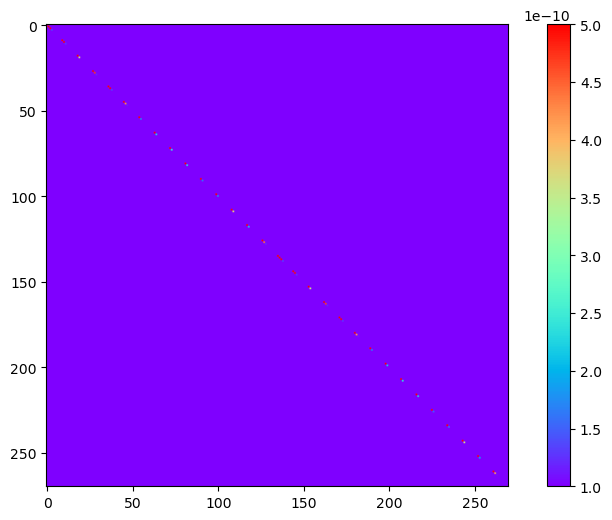

In [225]:
plt.figure(figsize=(10,6))
plt.imshow(pub2.data,cmap="rainbow", vmin=0.1e-9, vmax=0.5e-9)
plt.colorbar()
plt.show()

In [226]:
var = np.diag(pub2.data)
err = np.sqrt(var)
print(err), len(err)
print(var)

[8.72786336e-05 4.42374371e-05 2.25035636e-05 1.14867717e-05
 5.81708311e-06 2.94828654e-06 1.52942843e-06 8.17376815e-07
 4.78044706e-07 4.42801754e-05 2.22919032e-05 1.12785291e-05
 5.72611266e-06 2.89707805e-06 1.47951893e-06 7.82193966e-07
 4.29364354e-07 2.55610702e-07 3.80574977e-05 1.90691669e-05
 9.63062942e-06 4.89986444e-06 2.50113271e-06 1.30209027e-06
 7.09189551e-07 4.01585774e-07 2.41397977e-07 4.34215945e-05
 2.16946611e-05 1.09518803e-05 5.58575431e-06 2.87223963e-06
 1.51610236e-06 8.39512832e-07 4.80179092e-07 2.86902189e-07
 4.52003763e-05 2.26064598e-05 1.14309452e-05 5.84763725e-06
 3.02744636e-06 1.61629870e-06 9.04600905e-07 5.19573742e-07
 3.08536250e-07 3.98997213e-05 2.06351118e-05 1.06779163e-05
 5.51677913e-06 2.83288898e-06 1.47656399e-06 8.06080542e-07
 4.61017459e-07 2.82853861e-07 2.56487230e-05 1.30286195e-05
 6.67529868e-06 3.44173606e-06 1.78490567e-06 9.59317378e-07
 5.53676397e-07 3.38710337e-07 2.16333457e-07 2.98734539e-05
 1.50070315e-05 7.634316

In [227]:
err_xip_cat = err[0:135] 
err_xim_cat = err[135:270]

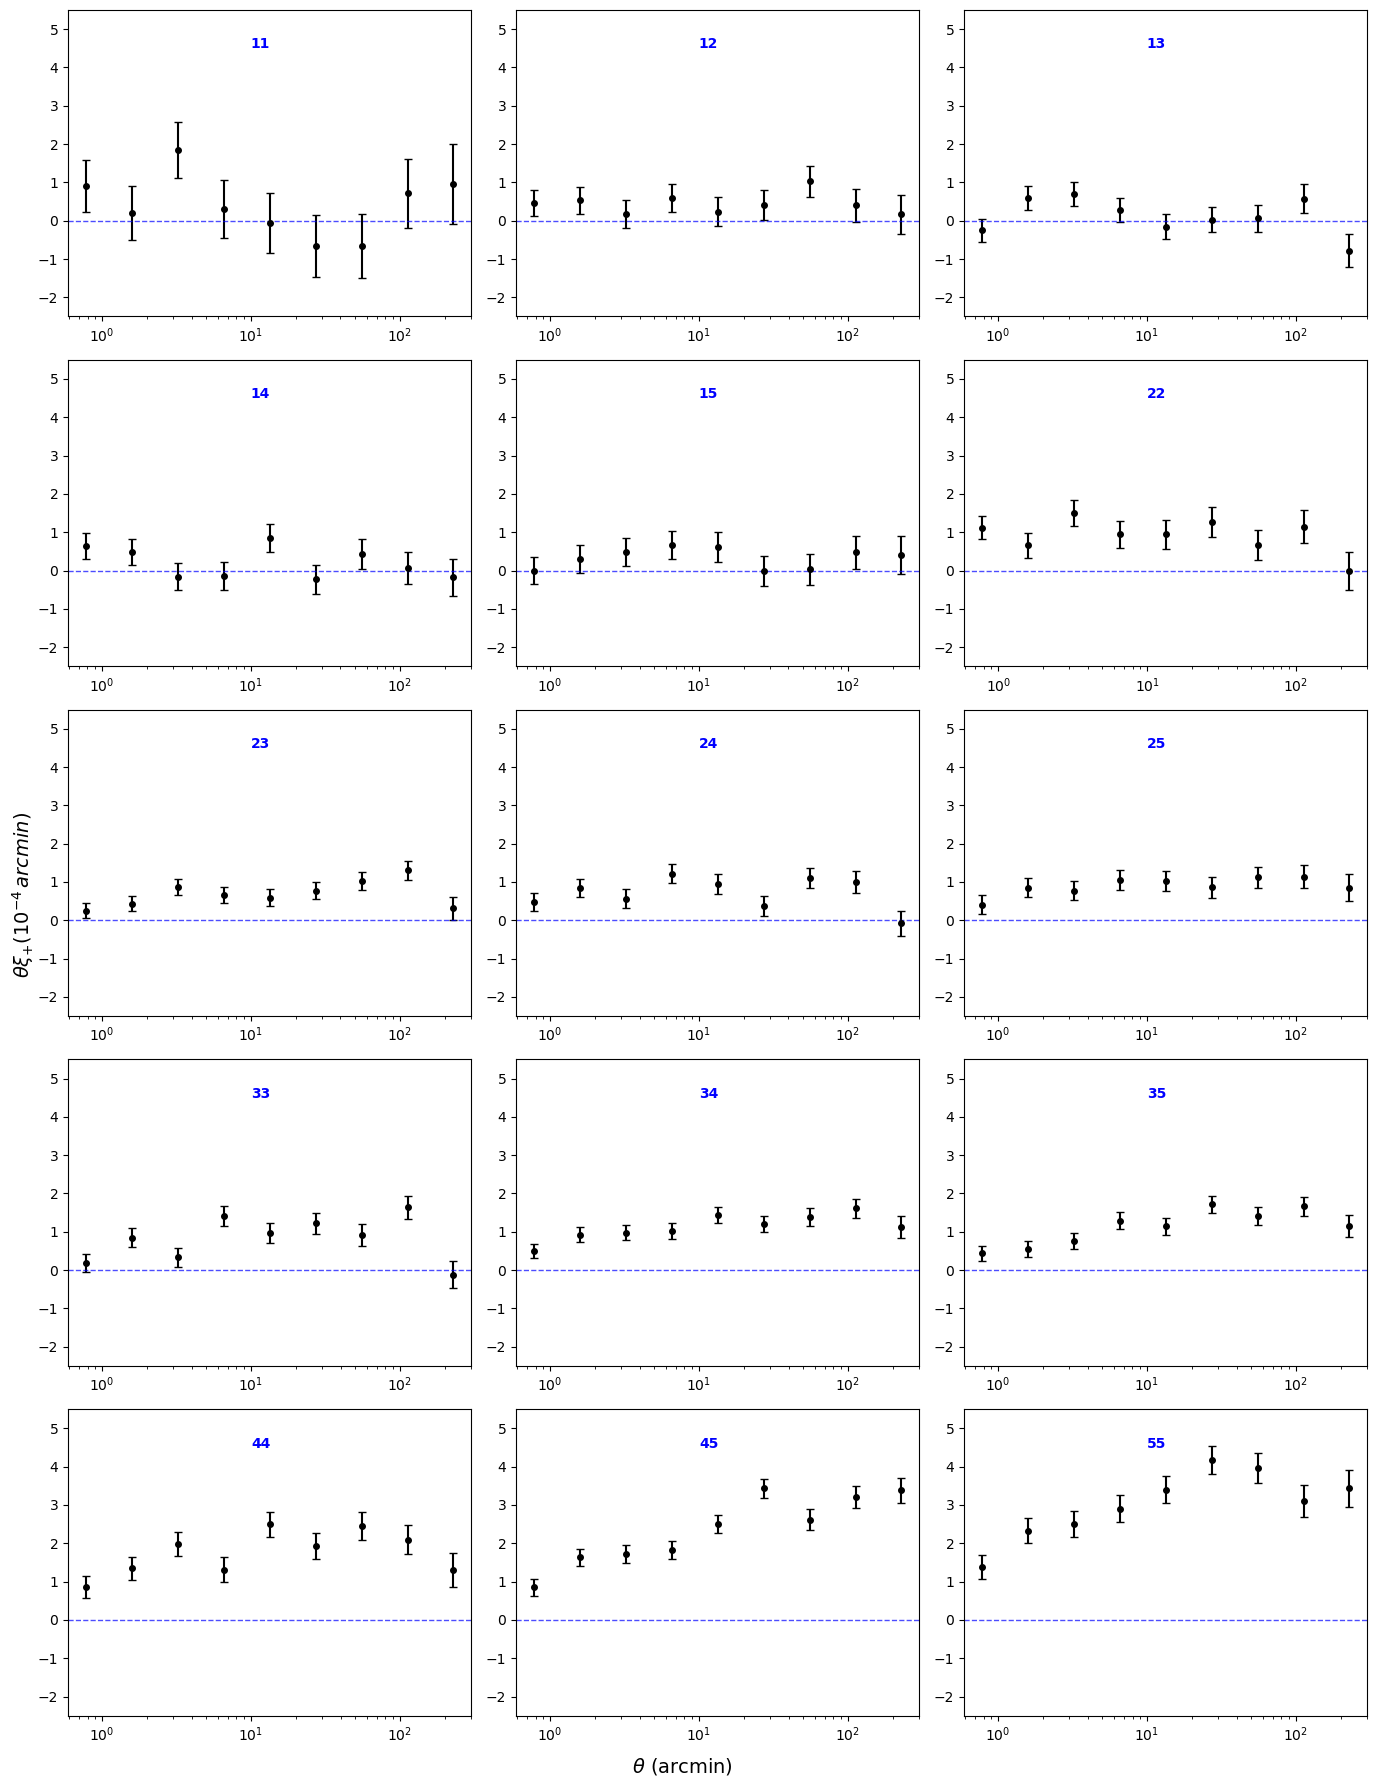

In [229]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18))
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    r = all_r[idx]
    xip = all_xip[idx]
    sig = all_sig_xip[idx]
    
    y = r * xip * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', markersize=4, capsize=3)
    
    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(10,4.5,f'{labels[idx]}', color='blue', fontweight='bold')
    # ax.set_xlabel(r'$\theta$ (arcmin)')
    # ax.set_ylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$')
    ax.set_ylim(-2.5, 5.5)
    ax.set_xscale('log')

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$', fontsize=14)
plt.tight_layout()
plt.savefig("xip1.png")
plt.show()

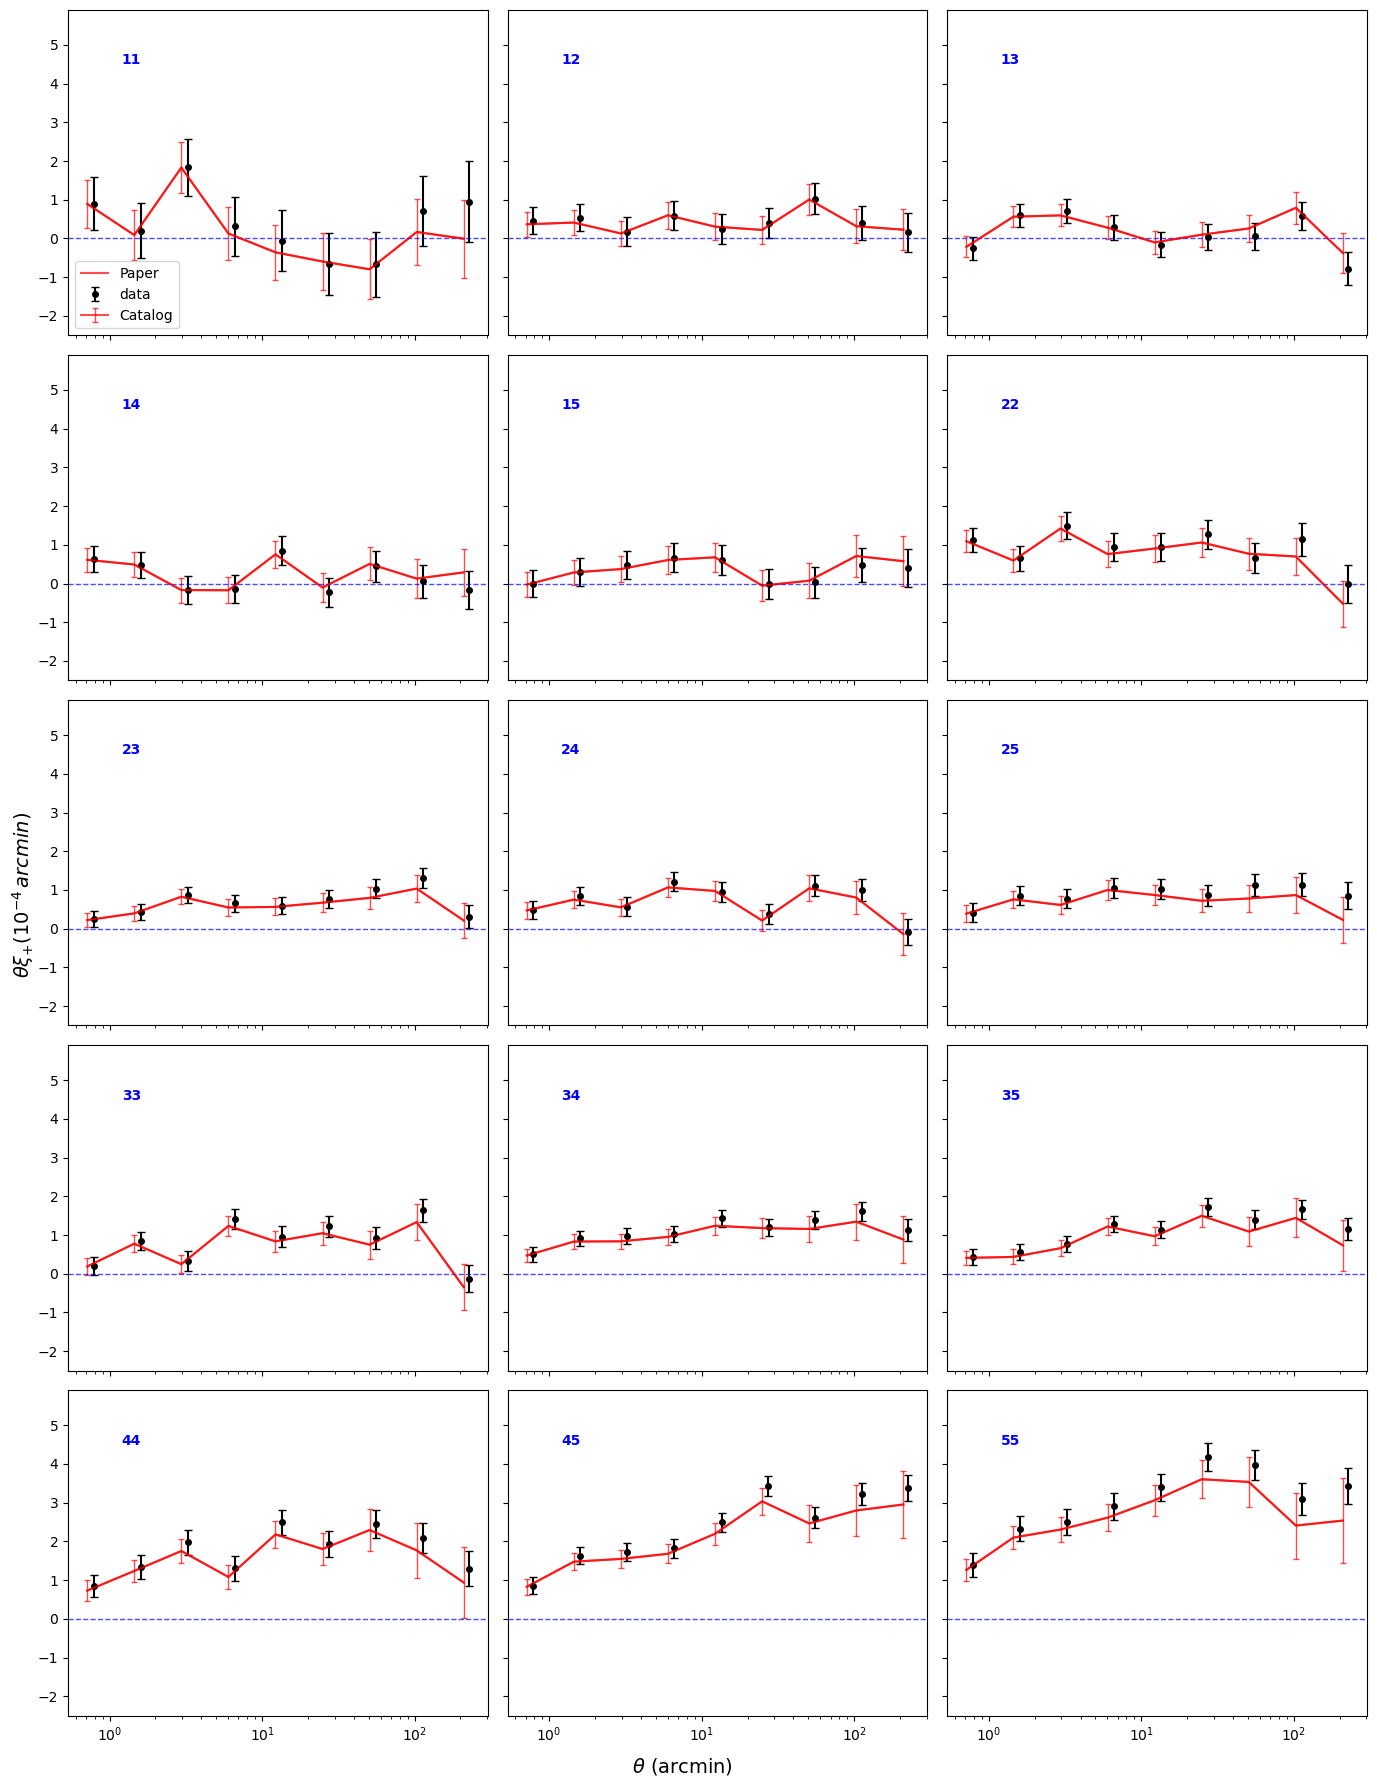

In [230]:
pub_data = pub.data  

pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    
    r = all_r[idx]
    xip = all_xip[idx]
    sig = all_sig_xip[idx]
    
    y = r * xip * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', 
                markersize=4, capsize=3, label='data')
    
    i, j = pairs[idx]
    mask = (pub_data['BIN1'] == i) & (pub_data['BIN2'] == j)
    pair_data = pub_data[mask]
    
    if len(pair_data) > 0:
        cat_theta = pair_data['ANG']
        cat_value = pair_data['VALUE']
        
        cat_y = cat_theta * cat_value * 10**4

        start_slice = idx * 9
        end_slice = (idx + 1) * 9
        cat_raw_err = err_xip_cat[start_slice:end_slice]

        cat_y_err = cat_theta * cat_raw_err * 10**4
        
        ax.plot(cat_theta, cat_y, '-', color='red', alpha=0.7, label='Paper')
        # ax.scatter(cat_theta, cat_y, color='red', s=15, alpha=0.7)
        ax.errorbar(x=cat_theta, y=cat_y, yerr=cat_y_err, fmt='-', color='red', 
                    ecolor='red', elinewidth=1, capsize=2, alpha=0.7, label='Catalog')

    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.text(1.2, 4.5, f'{labels[idx]}', color='blue', fontweight='bold', fontsize=10)
    
    ax.set_ylim(-2.5, 5.9)
    ax.set_xscale('log')
    
    if idx == 0:
        ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$', fontsize=14)

plt.tight_layout()
plt.savefig("xip1_compare.png")
plt.show()


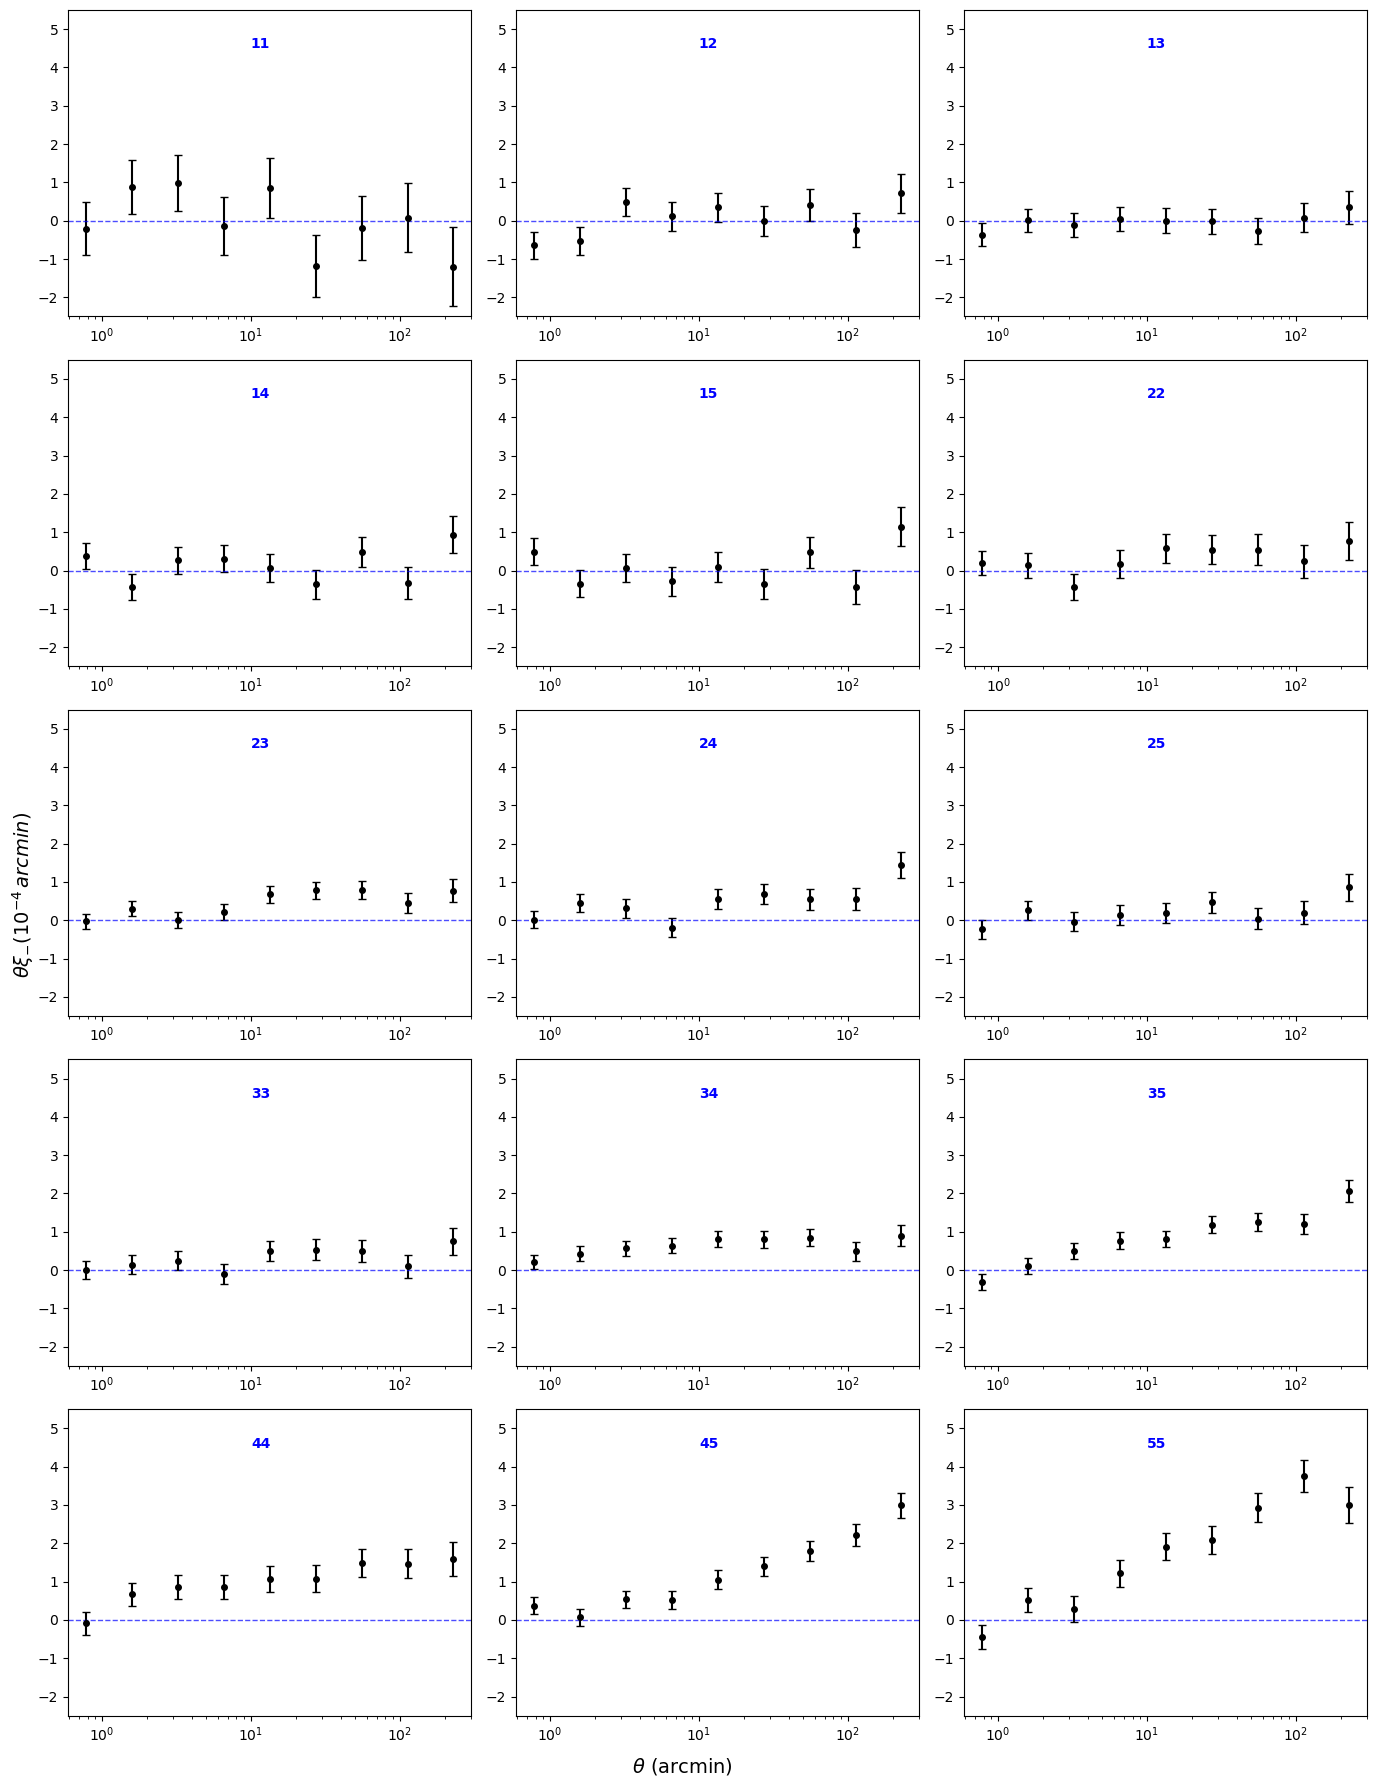

In [231]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18))
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    r = all_r[idx]
    xim = all_xim[idx]
    sig = all_sig_xim[idx]
    
    y = r * xim * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', markersize=4, capsize=3)
    
    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(10,4.5,f'{labels[idx]}', color='blue', fontweight='bold')
    # ax.set_xlabel(r'$\theta$ (arcmin)')
    # ax.set_ylabel(r'$\theta \xi_{+} ( 10^{-4} \,arcmin)$')
    ax.set_ylim(-2.5, 5.5)
    ax.set_xscale('log')

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{-} ( 10^{-4} \,arcmin)$', fontsize=14)
plt.tight_layout()
plt.savefig("xim1.png")
plt.show()

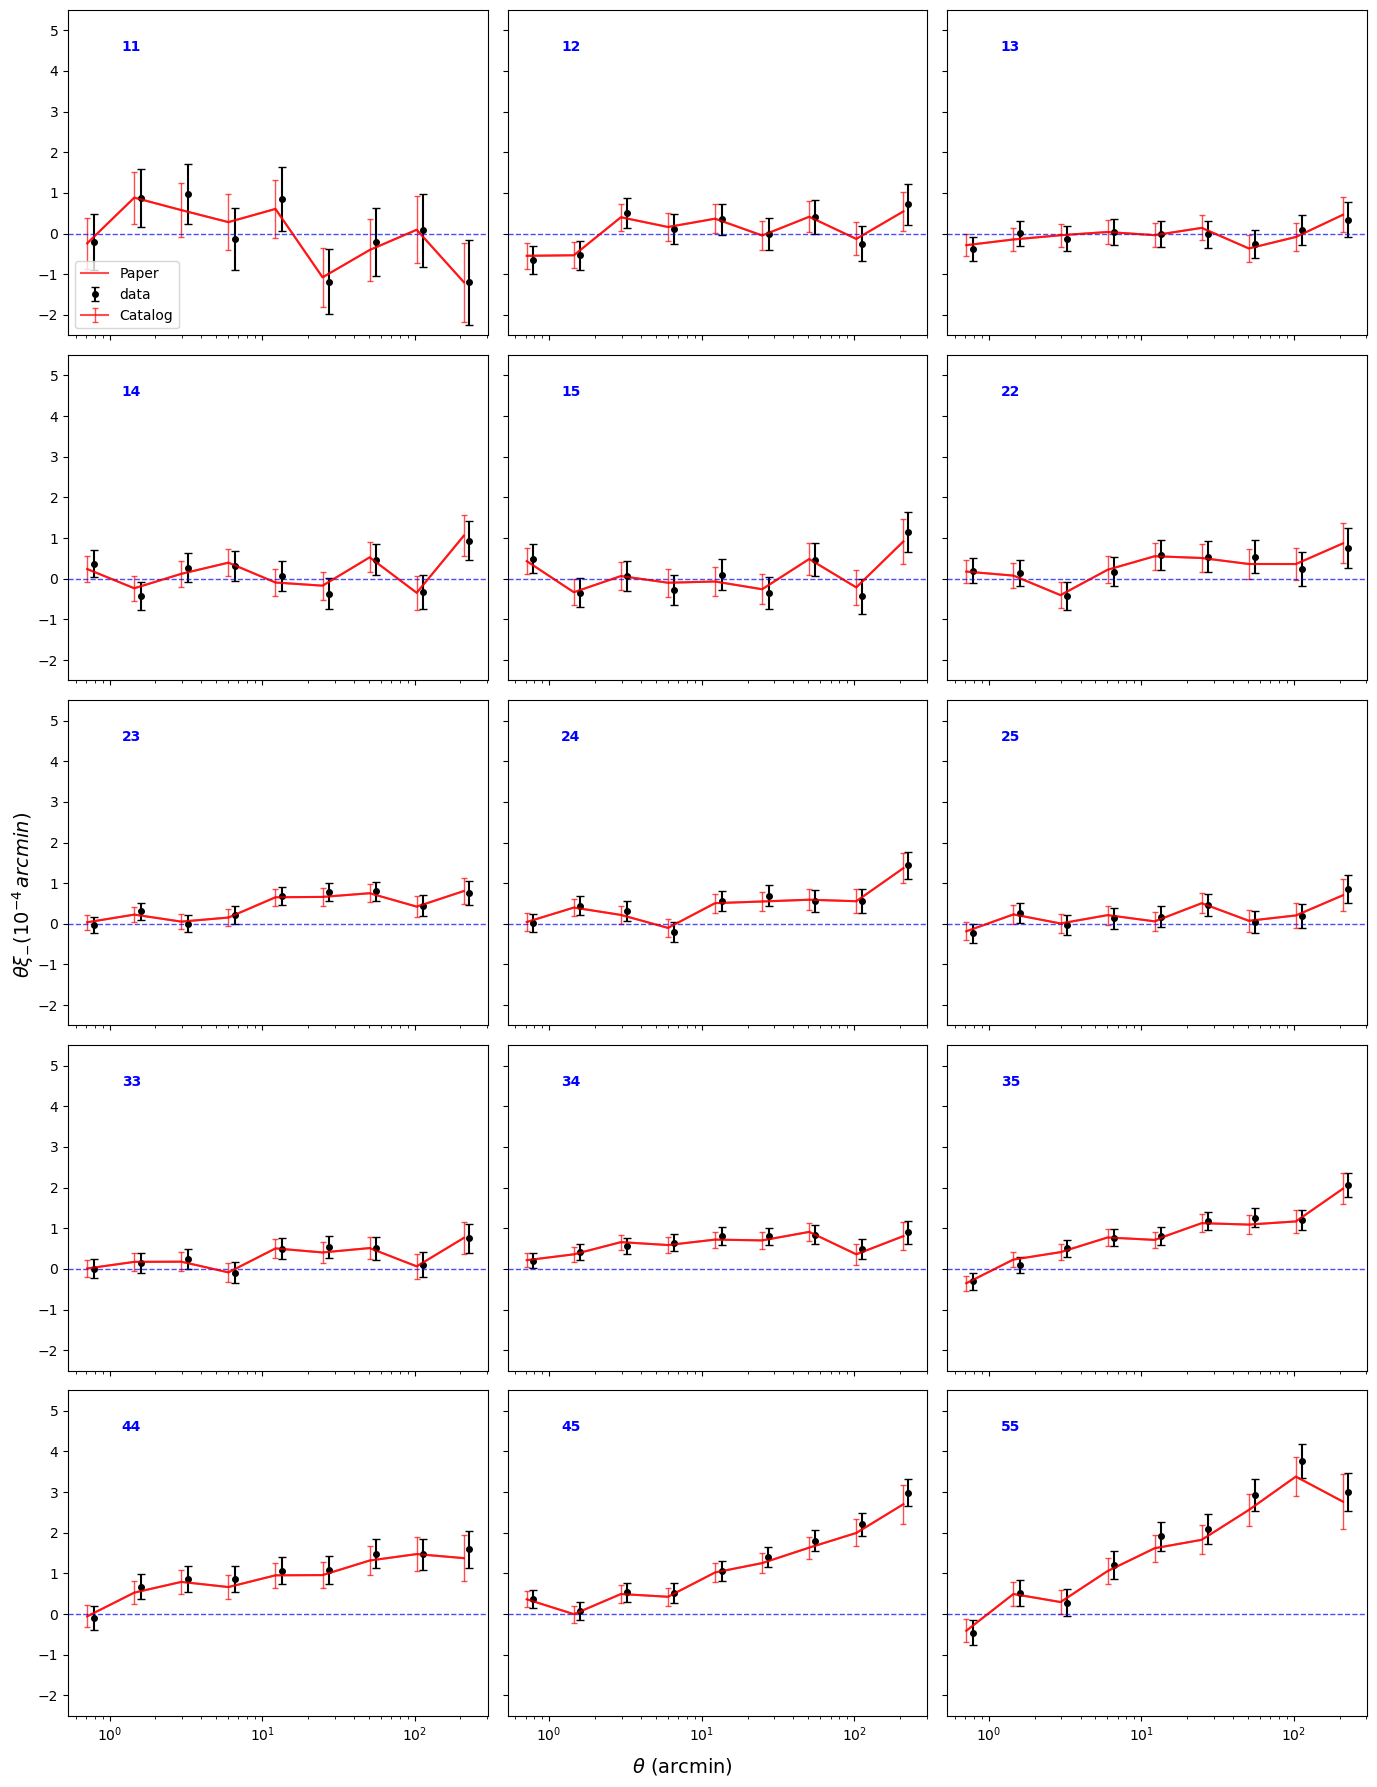

In [232]:
pub1_data = pub1.data  

pairs = [
    (1,1), (1,2), (1,3), (1,4), (1,5),
    (2,2), (2,3), (2,4), (2,5),
    (3,3), (3,4), (3,5),
    (4,4), (4,5),
    (5,5)
]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.flatten()

for idx in range(15):
    ax = axes[idx]
    
    r = all_r[idx]
    xim = all_xim[idx]
    sig = all_sig_xim[idx]
    
    y = r * xim * 10**4
    y_err = r * sig * 10**4
    
    ax.errorbar(x=r, y=y, yerr=y_err, fmt='o', color='black', 
                markersize=4, capsize=3, label='data')
    
    i, j = pairs[idx]
    mask = (pub1_data['BIN1'] == i) & (pub1_data['BIN2'] == j)
    pair_data = pub1_data[mask]
    
    if len(pair_data) > 0:
        cat_theta = pair_data['ANG']
        cat_value = pair_data['VALUE']
        
        cat_y = cat_theta * cat_value * 10**4

        start_slice = idx * 9
        end_slice = (idx + 1) * 9
        cat_raw_err = err_xim_cat[start_slice:end_slice]

        cat_y_err = cat_theta * cat_raw_err * 10**4
        
        ax.plot(cat_theta, cat_y, '-', color='red', alpha=0.7, label='Paper')
        # ax.scatter(cat_theta, cat_y, color='red', s=15, alpha=0.7)
        ax.errorbar(x=cat_theta, y=cat_y, yerr=cat_y_err, fmt='-', color='red', 
                    ecolor='red', elinewidth=1, capsize=2, alpha=0.7, label='Catalog')

    ax.axhline(0, color='blue', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.text(1.2, 4.5, f'{labels[idx]}', color='blue', fontweight='bold', fontsize=10)
    
    ax.set_ylim(-2.5, 5.5)
    ax.set_xscale('log')
    
    if idx == 0:
        ax.legend(loc='lower left', fontsize=10)

fig.supxlabel(r'$\theta$ (arcmin)', fontsize=14)
fig.supylabel(r'$\theta \xi_{-} ( 10^{-4} \,arcmin)$', fontsize=14)

plt.tight_layout()
plt.savefig("xim1_comp.png")
plt.show()
